In [1]:
# Importing libraries required for sales forecasting and model evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Loading the cleaned grocery sales dataset

df = pd.read_csv("/content/Supermart_Grocery_Cleaned.csv")

df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Order Year,Order Month,Month Number,Order Quarter,Profit Margin
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28,Tamil Nadu,2017,November,11,Q4,32.0
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80,Tamil Nadu,2017,November,11,Q4,20.0
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20,Tamil Nadu,2017,June,6,Q2,7.0
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60,Tamil Nadu,2016,October,10,Q4,10.0
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45,Tamil Nadu,2016,October,10,Q4,39.0


In [3]:
# Converting Order Date from text format into datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"])

print("Date conversion completed successfully.")

Date conversion completed successfully.


In [4]:
# Calculating total sales for every month

monthly_sales = (
    df.set_index("Order Date")["Sales"]
      .resample("MS")
      .sum()
)

monthly_sales

,Sales
Order Date,
2015-01-01,122497
2015-02-01,66030
2015-03-01,247156
2015-04-01,203258
2015-05-01,164263
2015-06-01,206064
2015-07-01,220986
2015-08-01,230161
2015-09-01,382200


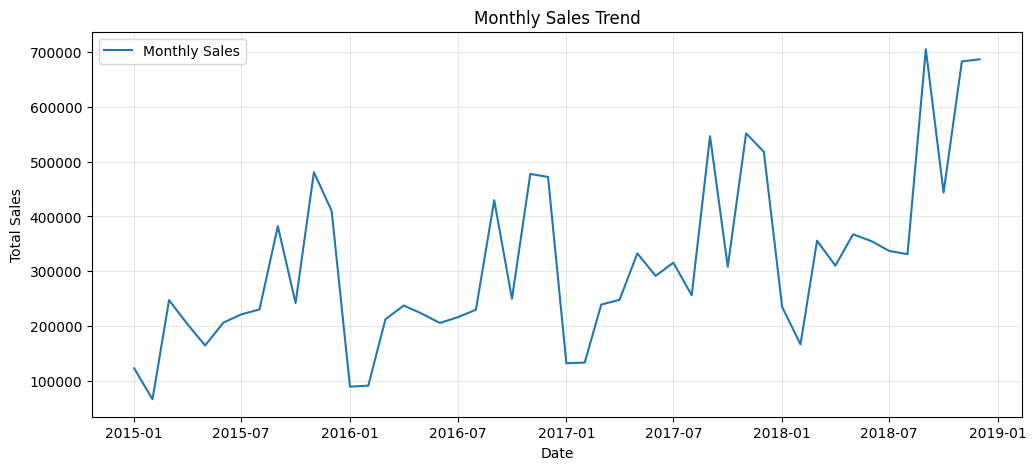

In [5]:
# Displaying the historical monthly sales trend

plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index, monthly_sales.values, label="Monthly Sales")

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [6]:
# Keeping the most recent 12 months for testing
# The remaining historical data will be used for training

train_data = monthly_sales.iloc[:-12]
test_data = monthly_sales.iloc[-12:]

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

Training observations: 36
Testing observations: 12


In [7]:
# Checking the training and testing periods

print("Training Period:")
print(train_data.index.min(), "to", train_data.index.max())

print("\nTesting Period:")
print(test_data.index.min(), "to", test_data.index.max())

Training Period:
2015-01-01 00:00:00 to 2017-12-01 00:00:00

Testing Period:
2018-01-01 00:00:00 to 2018-12-01 00:00:00


In [9]:
# Creating a Holt-Winters model
# Additive trend and yearly seasonal pattern are used

hw_model = ExponentialSmoothing(
    train_data,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

In [10]:
# Fitting the forecasting model on the training data

hw_fitted = hw_model.fit()

print("Holt-Winters model trained successfully.")

Holt-Winters model trained successfully.


In [11]:
# Forecasting sales for the 12-month testing period

test_predictions = hw_fitted.forecast(steps=12)

test_predictions

,0
2018-01-01,199697.054844
2018-02-01,203216.360874
2018-03-01,320767.988457
2018-04-01,337527.442519
2018-05-01,373806.202690
2018-06-01,348772.197156
2018-07-01,360323.495017
2018-08-01,374234.482843
2018-09-01,557939.492242
2018-10-01,400641.629364


In [12]:
# Calculating Mean Absolute Error (MAE)

mae = mean_absolute_error(test_data, test_predictions)

print("Mean Absolute Error (MAE):", round(mae, 2))

Mean Absolute Error (MAE): 44974.77


In [13]:
# Calculating Root Mean Squared Error (RMSE)

rmse = np.sqrt(
    mean_squared_error(test_data, test_predictions)
)

print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Root Mean Squared Error (RMSE): 58278.99


In [14]:
# Calculating Mean Absolute Percentage Error (MAPE)

mape = (
    np.mean(
        np.abs(
            (test_data.values - test_predictions.values)
            / test_data.values
        )
    ) * 100
)

print("Mean Absolute Percentage Error (MAPE):", round(mape, 2), "%")

Mean Absolute Percentage Error (MAPE): 10.8 %


In [15]:
# Creating a comparison table between actual and predicted sales

results = pd.DataFrame({
    "Actual Sales": test_data.values,
    "Predicted Sales": test_predictions.values
}, index=test_data.index)

results

,Actual Sales,Predicted Sales
Order Date,,
2018-01-01,234739,199697.054844
2018-02-01,166267,203216.360874
2018-03-01,355704,320767.988457
2018-04-01,310150,337527.442519
2018-05-01,367411,373806.202690
2018-06-01,354902,348772.197156
2018-07-01,337092,360323.495017
2018-08-01,331014,374234.482843
2018-09-01,705680,557939.492242


In [16]:
# Adding the difference between actual and predicted sales

results["Prediction Error"] = (
    results["Actual Sales"] - results["Predicted Sales"]
)

results

,Actual Sales,Predicted Sales,Prediction Error
Order Date,,,
2018-01-01,234739,199697.054844,35041.945156
2018-02-01,166267,203216.360874,-36949.360874
2018-03-01,355704,320767.988457,34936.011543
2018-04-01,310150,337527.442519,-27377.442519
2018-05-01,367411,373806.202690,-6395.202690
2018-06-01,354902,348772.197156,6129.802844
2018-07-01,337092,360323.495017,-23231.495017
2018-08-01,331014,374234.482843,-43220.482843
2018-09-01,705680,557939.492242,147740.507758


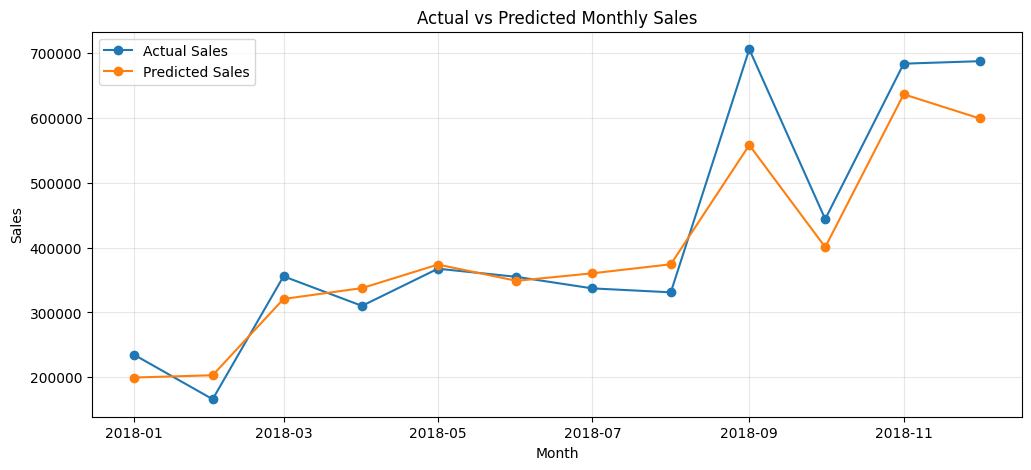

In [17]:
# Comparing actual sales with model predictions

plt.figure(figsize=(12, 5))

plt.plot(
    test_data.index,
    test_data.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test_predictions.index,
    test_predictions.values,
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [18]:
# Building the final forecasting model using the complete dataset

final_hw_model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

In [19]:
# Training the final model on all available monthly sales data

final_hw_fitted = final_hw_model.fit()

print("Final model trained using complete sales history.")

Final model trained using complete sales history.


In [20]:
# Saving the trained forecasting model for future use

final_hw_fitted.save("sales_forecasting_holt_winters.pkl")

print("Model saved successfully.")

Model saved successfully.


In [21]:
# Forecasting sales for the next six months

next_six_months = final_hw_fitted.forecast(steps=6)

next_six_months

,0
2019-01-01,346622.221606
2019-02-01,334886.915769
2019-03-01,484529.317015
2019-04-01,486868.518349
2019-05-01,535016.199659
2019-06-01,522484.092987


In [22]:
# Creating a clean table containing the future sales predictions

future_forecast = pd.DataFrame({
    "Forecasted Sales": next_six_months.round(2)
})

future_forecast.index.name = "Forecast Month"

future_forecast

,Forecasted Sales
Forecast Month,
2019-01-01,346622.22
2019-02-01,334886.92
2019-03-01,484529.32
2019-04-01,486868.52
2019-05-01,535016.20
2019-06-01,522484.09


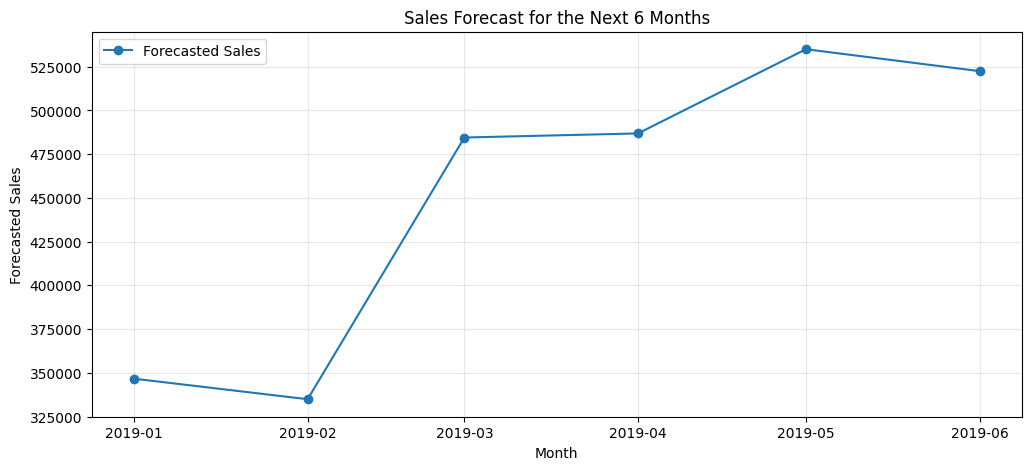

In [23]:
# Visualizing the six-month future sales forecast

plt.figure(figsize=(12, 5))

plt.plot(
    next_six_months.index,
    next_six_months.values,
    marker="o",
    label="Forecasted Sales"
)

plt.title("Sales Forecast for the Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

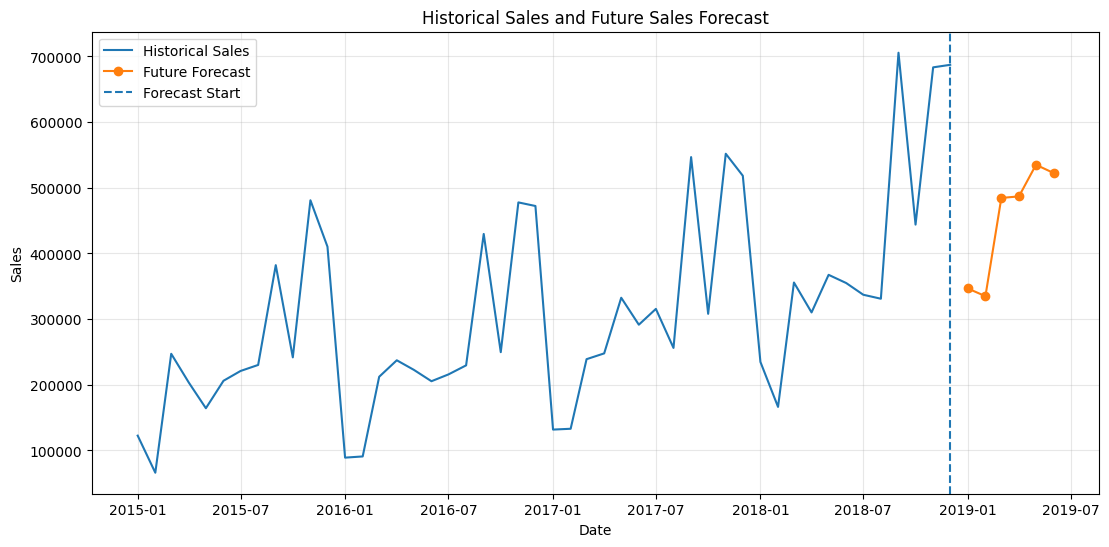

In [24]:
# Combining historical sales with future forecast for visualization

plt.figure(figsize=(13, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Historical Sales"
)

plt.plot(
    next_six_months.index,
    next_six_months.values,
    marker="o",
    label="Future Forecast"
)

plt.axvline(
    monthly_sales.index[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title("Historical Sales and Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [25]:
# Displaying the main forecasting performance results

print("===== SALES FORECASTING MODEL RESULTS =====")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

print("\nForecast for the next 6 months:")
print(future_forecast)

===== SALES FORECASTING MODEL RESULTS =====
MAE : 44974.77
RMSE: 58278.99
MAPE: 10.8 %

Forecast for the next 6 months:
                Forecasted Sales
Forecast Month                  
2019-01-01             346622.22
2019-02-01             334886.92
2019-03-01             484529.32
2019-04-01             486868.52
2019-05-01             535016.20
2019-06-01             522484.09


In [26]:
# Final interpretation of the forecasting model

print(
    f"""
The Holt-Winters Exponential Smoothing model was used to forecast
monthly grocery sales.

The model achieved a MAPE of {mape:.2f}% on the 12-month test period.
After evaluation, the model was retrained using the complete historical
sales dataset.

The final model was then used to estimate sales for the next six months.
"""
)


The Holt-Winters Exponential Smoothing model was used to forecast
monthly grocery sales.

The model achieved a MAPE of 10.80% on the 12-month test period.
After evaluation, the model was retrained using the complete historical
sales dataset.

The final model was then used to estimate sales for the next six months.

